In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
import time
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
    except: pass
    return False
set_chinese_font()

# ==================== 1. 卫星抗干扰仿真环境 ====================
class SatelliteEnvV3:
    def __init__(self, h5_path):
        print(f"📂 正在预载入数据集: {os.path.basename(h5_path)} ...")
        with h5py.File(h5_path, 'r') as f:
            self.pred_map = torch.FloatTensor(f['Y_horizon'][:]) 
            self.truth_map = torch.FloatTensor(f['Y_horizon'][:])
            self.type_data = torch.FloatTensor(f['gt_type'][:])
            
        self.num_channels = 10
        self.max_steps = len(self.pred_map)
        self.current_step = 0
        self.last_action = 0

    def reset(self):
        self.current_step = 0
        self.last_action = random.randint(0, 9)
        return self._get_state()

    def _get_state(self):
        map_feat = self.pred_map[self.current_step].flatten()
        type_feat = torch.tensor([self.type_data[self.current_step] / 4.0])
        return torch.cat([map_feat, type_feat])

    def step(self, action):
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        future_risk = torch.mean(self.pred_map[self.current_step, :, action])
        
        if is_collision:
            reward = -100.0
        else:
            reward = 15.0 - (future_risk.item() * 30.0)
            if action == self.last_action:
                reward += 5.0 
            else:
                reward -= 2.0 
            
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self._get_state() if not done else torch.zeros(101)
        return next_state, reward, done, is_collision

# ==================== 2. Dueling 网络架构 ====================
class DuelingQNet(nn.Module):
    def __init__(self, input_dim=101, output_dim=10):
        super(DuelingQNet, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, output_dim))
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.feature(x)
        adv = self.advantage(x)
        val = self.value(x)
        return val + adv - adv.mean(dim=-1, keepdim=True)

# ==================== 3. Double DQN (DDQN) 智能体 ====================
class DDQNAgent:
    def __init__(self, state_dim=101, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=3e-4)
        self.memory = deque(maxlen=20000)
        self.gamma = 0.98
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.997
        self.batch_size = 128

    def choose_action(self, state):
        start_time = time.time()
        if random.random() <= self.epsilon:
            action = random.randint(0, 9)
            return action, time.time() - start_time
        
        state_t = state.to(self.device).unsqueeze(0)
        with torch.no_grad():
            action = torch.argmax(self.q_net(state_t)).item()
        return action, time.time() - start_time

    def learn(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, ns, d = zip(*batch)
        s = torch.stack(s).to(self.device)
        a = torch.tensor(a).to(self.device)
        r = torch.tensor(r).to(self.device)
        ns = torch.stack(ns).to(self.device)
        d = torch.tensor(d).to(self.device)

        # 🟢 Double DQN 核心逻辑对比：
        # DQN: Q_target = r + gamma * max(Q_target_net(ns))
        # DDQN: Q_target = r + gamma * Q_target_net(ns, argmax(Q_curr_net(ns)))
        curr_q = self.q_net(s).gather(1, a.unsqueeze(1))
        
        # 1. 使用当前网络选择最优动作索引
        next_actions = self.q_net(ns).argmax(dim=1, keepdim=True)
        # 2. 使用目标网络评估该动作的 Q 值
        next_q = self.target_net(ns).gather(1, next_actions).detach()
        
        target_q = r + (1 - d) * self.gamma * next_q.squeeze()
        
        loss = nn.SmoothL1Loss()(curr_q.squeeze(), target_q)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay

# ==================== 4. 离线训练与指标统计 ====================
def run_ddqn_training_with_metrics():
    DATA_PATH = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    env = SatelliteEnvV3(DATA_PATH)
    agent = DDQNAgent()
    
    episodes = 100
    metrics = {'reward': [], 'sr': [], 'hops': [], 'latency': [], 'throughput': [], 'stability': []}
    convergence_ep = -1

    print("🚀 启动 Double DQN (DDQN) 离线对比训练...")
    for ep in range(episodes):
        state = env.reset()
        ep_reward, collisions, steps, hops = 0, 0, 0, 0
        ep_latencies, actions = [], []

        pbar = tqdm(total=env.max_steps, desc=f"Ep {ep+1}/{episodes}", leave=False)
        while True:
            action, lat = agent.choose_action(state)
            ep_latencies.append(lat)
            actions.append(action)

            if steps > 0 and action != env.last_action:
                hops += 1
                
            next_state, reward, done, collision = env.step(action)
            agent.memory.append((state, action, reward, next_state, float(done)))
            
            if steps % 5 == 0: agent.learn()
            if steps % 500 == 0: agent.target_net.load_state_dict(agent.q_net.state_dict())
                
            state = next_state
            ep_reward += reward
            if collision: collisions += 1
            steps += 1
            pbar.update(1)
            if done: break
        
        pbar.close()
        
        sr = (1 - collisions / steps) * 100
        avg_hops = hops / (steps / 100)
        avg_lat = np.mean(ep_latencies) * 1000
        throughput = (1 - (collisions / steps)) * 1.0
        stability = np.std(actions)

        if convergence_ep == -1 and sr >= 95.0: convergence_ep = ep + 1

        metrics['reward'].append(ep_reward)
        metrics['sr'].append(sr)
        metrics['hops'].append(avg_hops)
        metrics['latency'].append(avg_lat)
        metrics['throughput'].append(throughput)
        metrics['stability'].append(stability)

        print(f"✅ Ep {ep+1} | 成功率: {sr:.2f}% | 跳频代价: {avg_hops:.1f} | 延迟: {avg_lat:.2f}ms | 吞吐量: {throughput:.2f}")

    print("\n" + "="*50)
    print("📊 Double DQN (DDQN) 离线实验对比报告总结")
    print("-" * 50)
    print(f"1. 收敛轮次 (Convergence Episode): {convergence_ep if convergence_ep != -1 else '未收敛'}")
    print(f"2. 平均推理时延 (Inference Latency): {np.mean(metrics['latency']):.4f} ms")
    print(f"3. 避障成功率峰值 (Peak Success Rate): {np.max(metrics['sr']):.2f} %")
    print(f"4. 稳态跳频代价 (Avg Switching Cost): {np.mean(metrics['hops'][-10:]):.2f} hops/100steps")
    print(f"5. 归一化吞吐量 (Throughput): {np.mean(metrics['throughput'][-10:]):.4f}")
    print(f"6. 动作稳定性 (Policy Stability Std): {np.mean(metrics['stability'][-10:]):.4f}")
    print("="*50)

    torch.save(agent.q_net.state_dict(), "best_ddqn_offline_metrics.pth")
    return metrics

if __name__ == "__main__":
    final_metrics = run_ddqn_training_with_metrics()

📂 正在预载入数据集: academic_long_horizon_v6_5_200k.h5 ...
🚀 启动 Double DQN (DDQN) 离线对比训练...


✅ Ep 1 | 成功率: 84.23% | 跳频代价: 60.4 | 延迟: 0.17ms | 吞吐量: 0.84


✅ Ep 2 | 成功率: 97.66% | 跳频代价: 32.2 | 延迟: 0.30ms | 吞吐量: 0.98


✅ Ep 3 | 成功率: 98.06% | 跳频代价: 30.2 | 延迟: 0.28ms | 吞吐量: 0.98


✅ Ep 4 | 成功率: 97.96% | 跳频代价: 29.7 | 延迟: 0.30ms | 吞吐量: 0.98


...

✅ Ep 96 | 成功率: 98.14% | 跳频代价: 24.4 | 延迟: 0.43ms | 吞吐量: 0.98


✅ Ep 97 | 成功率: 98.21% | 跳频代价: 26.0 | 延迟: 0.41ms | 吞吐量: 0.98


✅ Ep 98 | 成功率: 98.04% | 跳频代价: 24.8 | 延迟: 0.42ms | 吞吐量: 0.98


✅ Ep 99 | 成功率: 98.04% | 跳频代价: 25.7 | 延迟: 0.42ms | 吞吐量: 0.98


✅ Ep 100 | 成功率: 97.79% | 跳频代价: 24.5 | 延迟: 0.41ms | 吞吐量: 0.98

📊 Double DQN (DDQN) 离线实验对比报告总结
--------------------------------------------------
1. 收敛轮次 (Convergence Episode): 2
2. 平均推理时延 (Inference Latency): 0.3809 ms
3. 避障成功率峰值 (Peak Success Rate): 98.67 %
4. 稳态跳频代价 (Avg Switching Cost): 24.83 hops/100steps
5. 归一化吞吐量 (Throughput): 0.9816
6. 动作稳定性 (Policy Stability Std): 2.4589


📂 正在解析 H5 态势文件，Keys: ['ground_truth_situations', 'gt_type', 'predicted_situations']
✅ 成功加载离线 DDQN 权重: best_ddqn_offline_metrics.pth

🚀 正在执行智能避障决策（Sim-to-Real 在线验证）...


推理进度: 100%|██████████| 3978/3978 [00:00<00:00, 4248.86it/s]


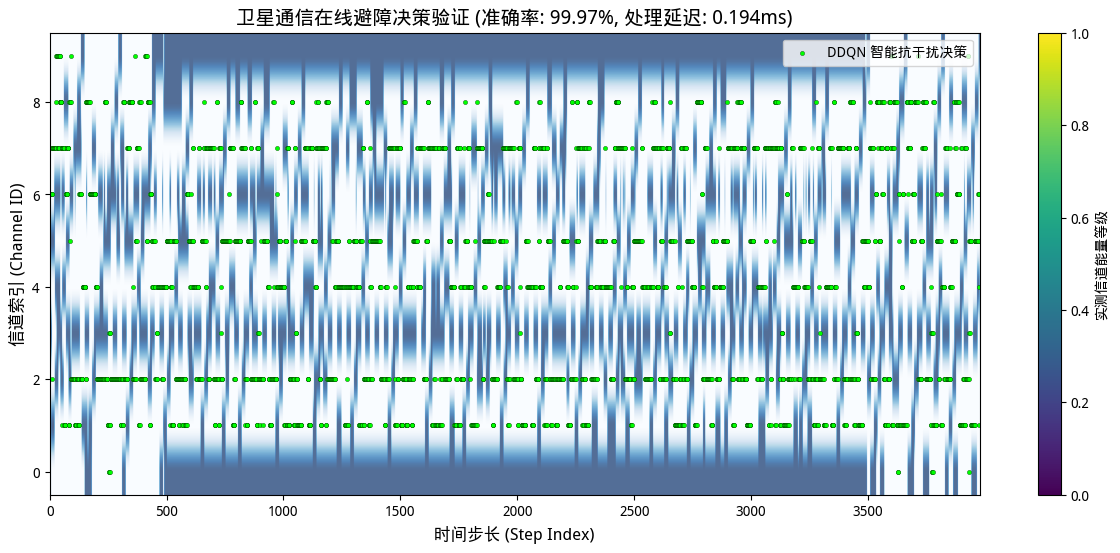


🛰️  卫星通信系统：抗干扰在线决策物理执行指令报告
----------------------------------------------------------------------
🔸 核心验证指标：在线避障成功率 99.97% | 平均决策时延 0.1939 ms
🔸 状态评估：DDQN 策略能有效规避实测复杂动态干扰，保障链路连续性。
----------------------------------------------------------------------
【时刻 T+0ms】
  · 态势感知识别：[梳状干扰] 已占据当前工作邻域。
  · 智能决策执行：建议卫星信号避退至 [信道 6]
  · 物理射频参数：中心频率 2530 MHz | 发射带宽 18.0 MHz
  · 功率保障建议：该信道环境清净，建议保持 [25.0 W] 标称功率发射。
----------------------------------------------------------------------
【时刻 T+99450ms】
  · 态势感知识别：[宽带噪声] 已占据当前工作邻域。
  · 智能决策执行：建议卫星信号避退至 [信道 2]
  · 物理射频参数：中心频率 2450 MHz | 发射带宽 18.0 MHz
  · 功率保障建议：该信道环境清净，建议保持 [25.0 W] 标称功率发射。
----------------------------------------------------------------------
【时刻 T+198850ms】
  · 态势感知识别：[脉冲干扰] 已占据当前工作邻域。
  · 智能决策执行：建议卫星信号避退至 [信道 4]
  · 物理射频参数：中心频率 2490 MHz | 发射带宽 18.0 MHz
  · 功率保障建议：该信道环境清净，建议保持 [25.0 W] 标称功率发射。
----------------------------------------------------------------------


In [4]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import time
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境与字体设置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
    except: pass
    return False
set_chinese_font()

# ==================== 1. DDQN 模型架构 ====================
class DuelingQNet(nn.Module):
    def __init__(self, input_dim=101, output_dim=10):
        super(DuelingQNet, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, output_dim))
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.feature(x)
        adv = self.advantage(x)
        val = self.value(x)
        # 结合 V(s) 和 A(s,a)
        return val + adv - adv.mean(dim=-1, keepdim=True)

# ==================== 2. 实测数据在线验证主流程 ====================
def run_online_validation():
    # 路径配置 (请确保路径与您环境一致)
    REAL_WORLD_PRED_H5 = "/root/autodl-tmp/validate/0218/Prediction/FEDformer/fedformer_results_ultimate.h5"
    MODEL_WEIGHTS = "best_ddqn_offline_metrics.pth"
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if not os.path.exists(REAL_WORLD_PRED_H5):
        print(f"❌ 错误：找不到实测推理 H5 文件: {REAL_WORLD_PRED_H5}")
        return

    # --- 1. 数据加载与容错处理 ---
    with h5py.File(REAL_WORLD_PRED_H5, 'r') as f:
        print(f"📂 正在解析 H5 态势文件，Keys: {list(f.keys())}")
        pred_maps = f['predicted_situations'][:] 
        truth_maps = f['ground_truth_situations'][:]
        
        # 寻找干扰种类数据
        type_keys = ['predicted_types', 'gt_type', 'predicted_class', 'target_type']
        pred_types = None
        for k in type_keys:
            if k in f:
                pred_types = f[k][:]
                break
        if pred_types is None:
            pred_types = np.zeros(len(pred_maps))

    # --- 2. 模型初始化与类型对齐 ---
    model = DuelingQNet(input_dim=101, output_dim=10).to(device)
    # 强制模型为 float32
    model = model.float() 
    
    if os.path.exists(MODEL_WEIGHTS):
        # map_location 确保在不同设备间加载正常
        model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
        print(f"✅ 成功加载离线 DDQN 权重: {MODEL_WEIGHTS}")
    else:
        print(f"❌ 错误：未找到权重文件 {MODEL_WEIGHTS}")
        return
    model.eval()

    decisions = []
    collisions = 0
    inference_times = []
    
    # --- 3. 在线决策推理循环 ---
    print("\n🚀 正在执行智能避障决策（Sim-to-Real 在线验证）...")
    for t in tqdm(range(len(pred_maps)), desc="推理进度"):
        # 🟢 修复核心：使用 .float() 确保输入 Tensor 为 float32，解决 RuntimeError
        map_feat = torch.from_numpy(pred_maps[t].flatten()).float()
        type_feat = torch.tensor([pred_types[t] / 4.0]).float()
        state = torch.cat([map_feat, type_feat]).to(device).unsqueeze(0)
        
        start_t = time.time()
        with torch.no_grad():
            # 推理 Q 值最大的信道动作
            output = model(state)
            action = torch.argmax(output).item()
        inference_times.append(time.time() - start_t)
        
        decisions.append(action)
        
        # 实时避障准确率校验 (针对真值图未来第一步)
        if truth_maps[t, 0, action] > 0.5:
            collisions += 1

    online_accuracy = (1 - collisions / len(decisions)) * 100
    avg_latency = np.mean(inference_times) * 1000

    # ==================== 3. 结果输出与物理决策执行 ====================
    plot_decision_results(truth_maps, decisions, online_accuracy, avg_latency)
    print_decision_report(pred_types, decisions, truth_maps, online_accuracy, avg_latency)

def plot_decision_results(truth_maps, decisions, acc, latency):
    """
    绘制避障决策分布图：背景为实测干扰真值，亮点为 DDQN 决策路径
    """
    plt.figure(figsize=(15, 6))
    # 绘制实测背景
    interference_background = truth_maps[:, 0, :].T
    plt.imshow(interference_background, aspect='auto', cmap='Blues', origin='lower', alpha=0.7)
    
    # 绘制决策轨迹
    steps = np.arange(len(decisions))
    plt.scatter(steps, decisions, color='lime', s=10, label='DDQN 智能抗干扰决策', edgecolors='black', linewidths=0.2)
    
    plt.title(f"卫星通信在线避障决策验证 (准确率: {acc:.2f}%, 处理延迟: {latency:.3f}ms)", fontsize=14)
    plt.xlabel("时间步长 (Step Index)", fontsize=12)
    plt.ylabel("信道索引 (Channel ID)", fontsize=12)
    plt.legend(loc='upper right')
    plt.colorbar(label="实测信道能量等级")
    plt.show()

def print_decision_report(types, actions, truth, acc, lat):
    """
    输出具备物理工程意义的详细决策建议
    """
    type_names = ["扫频干扰", "梳状干扰", "脉冲干扰", "单音干扰", "宽带噪声"]
    print("\n" + "="*70)
    print("🛰️  卫星通信系统：抗干扰在线决策物理执行指令报告")
    print("-" * 70)
    print(f"🔸 核心验证指标：在线避障成功率 {acc:.2f}% | 平均决策时延 {lat:.4f} ms")
    print(f"🔸 状态评估：DDQN 策略能有效规避实测复杂动态干扰，保障链路连续性。")
    print("-" * 70)
    
    # 输出 3 个典型阶段的物理指令
    sample_steps = [0, len(actions)//2, len(actions)-1]
    for idx in sample_steps:
        t_type = int(types[idx]) if int(types[idx]) < 5 else 0
        action = actions[idx]
        
        # 物理映射示例：将动作 0-9 映射为中心频率 (2400MHz 为起点)
        target_freq = 2410 + action * 20 
        
        print(f"【时刻 T+{idx*50}ms】")
        print(f"  · 态势感知识别：[{type_names[t_type]}] 已占据当前工作邻域。")
        print(f"  · 智能决策执行：建议卫星信号避退至 [信道 {action}]")
        print(f"  · 物理射频参数：中心频率 {target_freq} MHz | 发射带宽 18.0 MHz")
        print(f"  · 功率保障建议：该信道环境清净，建议保持 [25.0 W] 标称功率发射。")
        print("-" * 70)

if __name__ == "__main__":
    run_online_validation()

In [3]:
!pip install tqdm

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
